# Paired FP32 vs INT8 HANS Analysis

This notebook compares **paired HANS predictions** from each frozen FP32 model and its corresponding dynamically quantized INT8 model.

### Main questions
1. Does INT8 quantization change overall HANS accuracy?
2. Where do predictions flip after quantization?
3. Are changes concentrated in particular **gold labels**, **heuristics**, or **subcases**?
4. Does quantization shift entailment/non-entailment probabilities even when the final prediction does not change?
5. Are observed effects consistent across seeds?
6. Are paired accuracy/probability changes statistically distinguishable from zero?

### Experimental pairing
- FP32 seed 42 ↔ INT8 seed 42
- FP32 seed 123 ↔ INT8 seed 123
- FP32 seed 456 ↔ INT8 seed 456

The notebook never pairs different seeds and never relies on CSV row order. Rows are matched by `pairID`.

### Sign conventions
- `delta_accuracy = INT8 accuracy - FP32 accuracy`
- `delta_prob_entailment = INT8 P(entailment) - FP32 P(entailment)`
- `delta_prob_non_entailment = INT8 P(non-entailment) - FP32 P(non-entailment)`

Therefore, a **positive entailment probability delta** means quantization pushed the model toward entailment.

## 1. Imports
This notebook only analyzes saved predictions; it does **not** load BERT or rerun inference.

In [1]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import binomtest, wilcoxon
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is not installed. Statistical-test cells will be skipped.")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("SciPy available:", SCIPY_AVAILABLE)

SciPy available: True


## 2. Configuration

Update `RESULTS_DIR` only if your prediction files live elsewhere.

Expected filenames by default:

```text
results/hans/
    fp32_seed42_predictions.csv
    fp32_seed123_predictions.csv
    fp32_seed456_predictions.csv
    int8_seed42_predictions.csv
    int8_seed123_predictions.csv
    int8_seed456_predictions.csv
```

If your teammate uses different names, edit `FP32_FILES` / `INT8_FILES`.

In [2]:
SEEDS = [42, 123, 456]

RESULTS_DIR = Path("../results/hans")

FP32_FILES = {
    seed: RESULTS_DIR / f"fp32_seed{seed}_predictions.csv"
    for seed in SEEDS
}

INT8_FILES = {
    seed: RESULTS_DIR / f"int8_seed{seed}_predictions.csv"
    for seed in SEEDS
}

OUTPUT_DIR = RESULTS_DIR / "paired_fp32_int8"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for seed in SEEDS:
    print(
        f"Seed {seed}:\n"
        f"  FP32: {FP32_FILES[seed]} {'✓' if FP32_FILES[seed].exists() else 'MISSING'}\n"
        f"  INT8: {INT8_FILES[seed]} {'✓' if INT8_FILES[seed].exists() else 'MISSING'}"
    )

Seed 42:
  FP32: ../results/hans/fp32_seed42_predictions.csv ✓
  INT8: ../results/hans/int8_seed42_predictions.csv ✓
Seed 123:
  FP32: ../results/hans/fp32_seed123_predictions.csv ✓
  INT8: ../results/hans/int8_seed123_predictions.csv ✓
Seed 456:
  FP32: ../results/hans/fp32_seed456_predictions.csv ✓
  INT8: ../results/hans/int8_seed456_predictions.csv ✓


## 3. Required schema

The analysis expects the same schema produced by the existing HANS evaluation notebook.  
`pairID` is the pairing key.

The probability columns allow us to study behavioral shifts that do not necessarily cross the final classification boundary.

In [3]:
REQUIRED_COLUMNS = {
    "pairID",
    "gold_label",
    "heuristic",
    "subcase",
    "hans_prediction",
    "correct",
    "prob_entailment",
    "prob_neutral",
    "prob_contradiction",
    "prob_non_entailment",
}

OPTIONAL_MATCH_COLUMNS = [
    "premise",
    "hypothesis",
    "template",
]

## 4. Loading and validation helpers

These checks intentionally fail loudly if FP32 and INT8 outputs cannot be paired safely.

For every seed we verify:
- required columns exist;
- `pairID` is unique;
- FP32 and INT8 contain exactly the same `pairID`s;
- gold label / heuristic / subcase match for each paired example;
- optional metadata such as premise, hypothesis and template also match when present.

In [4]:
def load_predictions(path):
    df = pd.read_csv(path)

    missing = REQUIRED_COLUMNS - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    if df["pairID"].isna().any():
        raise ValueError(f"{path}: pairID contains missing values.")

    if df["pairID"].duplicated().any():
        duplicates = df.loc[df["pairID"].duplicated(), "pairID"].head().tolist()
        raise ValueError(f"{path}: duplicate pairID values found, e.g. {duplicates}")

    # Normalize correctness in case CSV serialization changed boolean dtype.
    if df["correct"].dtype != bool:
        mapping = {
            "true": True, "false": False,
            "1": True, "0": False,
            1: True, 0: False,
            True: True, False: False,
        }
        converted = df["correct"].map(
            lambda x: mapping.get(str(x).lower(), mapping.get(x, np.nan))
        )
        if converted.isna().any():
            raise ValueError(f"{path}: could not interpret some values in 'correct'.")
        df["correct"] = converted.astype(bool)

    return df


def validate_pair(fp32, int8, seed):
    fp_ids = set(fp32["pairID"])
    int8_ids = set(int8["pairID"])

    if fp_ids != int8_ids:
        only_fp = list(fp_ids - int8_ids)[:5]
        only_int8 = list(int8_ids - fp_ids)[:5]
        raise ValueError(
            f"Seed {seed}: pairID mismatch. "
            f"Only FP32 examples: {only_fp}; only INT8 examples: {only_int8}"
        )

    match_cols = ["gold_label", "heuristic", "subcase"]
    match_cols += [
        c for c in OPTIONAL_MATCH_COLUMNS
        if c in fp32.columns and c in int8.columns
    ]

    left = fp32[["pairID"] + match_cols].copy()
    right = int8[["pairID"] + match_cols].copy()

    check = left.merge(
        right,
        on="pairID",
        suffixes=("_fp32", "_int8"),
        validate="one_to_one"
    )

    for col in match_cols:
        a = check[f"{col}_fp32"].fillna("<NA>").astype(str)
        b = check[f"{col}_int8"].fillna("<NA>").astype(str)
        if not a.equals(b):
            bad = check.loc[a != b, ["pairID", f"{col}_fp32", f"{col}_int8"]].head()
            raise ValueError(
                f"Seed {seed}: metadata mismatch in '{col}'.\n{bad}"
            )

    print(f"Seed {seed}: validation passed ({len(fp32):,} paired examples).")

## 5. Build the paired dataset

We keep FP32 and INT8 outputs side-by-side and derive:
- whether the HANS prediction flipped;
- correct → wrong and wrong → correct transitions;
- probability changes;
- change in probability assigned to the **gold HANS label**.

`delta_prob_gold > 0` means INT8 assigns **more probability to the correct HANS label** than FP32.

In [5]:
def build_paired_seed(fp32_path, int8_path, seed):
    fp32 = load_predictions(fp32_path)
    int8 = load_predictions(int8_path)

    validate_pair(fp32, int8, seed)

    metadata_cols = [
        "pairID", "gold_label", "heuristic", "subcase"
    ]
    metadata_cols += [
        c for c in OPTIONAL_MATCH_COLUMNS
        if c in fp32.columns and c in int8.columns
    ]

    fp_keep = metadata_cols + [
        "hans_prediction", "correct",
        "prob_entailment", "prob_neutral",
        "prob_contradiction", "prob_non_entailment",
    ]

    int8_keep = metadata_cols + [
        "hans_prediction", "correct",
        "prob_entailment", "prob_neutral",
        "prob_contradiction", "prob_non_entailment",
    ]

    paired = fp32[fp_keep].merge(
        int8[int8_keep],
        on=metadata_cols,
        suffixes=("_fp32", "_int8"),
        validate="one_to_one",
    )

    paired["seed"] = seed

    paired["prediction_flip"] = (
        paired["hans_prediction_fp32"] != paired["hans_prediction_int8"]
    )

    paired["correct_to_wrong"] = (
        paired["correct_fp32"] & ~paired["correct_int8"]
    )

    paired["wrong_to_correct"] = (
        ~paired["correct_fp32"] & paired["correct_int8"]
    )

    paired["correct_to_correct"] = (
        paired["correct_fp32"] & paired["correct_int8"]
    )

    paired["wrong_to_wrong"] = (
        ~paired["correct_fp32"] & ~paired["correct_int8"]
    )

    for prob in [
        "prob_entailment",
        "prob_neutral",
        "prob_contradiction",
        "prob_non_entailment",
    ]:
        paired[f"delta_{prob}"] = (
            paired[f"{prob}_int8"] - paired[f"{prob}_fp32"]
        )

    # HANS is binary: entailment vs non-entailment.
    paired["prob_gold_fp32"] = np.where(
        paired["gold_label"].eq("entailment"),
        paired["prob_entailment_fp32"],
        paired["prob_non_entailment_fp32"],
    )
    paired["prob_gold_int8"] = np.where(
        paired["gold_label"].eq("entailment"),
        paired["prob_entailment_int8"],
        paired["prob_non_entailment_int8"],
    )
    paired["delta_prob_gold"] = (
        paired["prob_gold_int8"] - paired["prob_gold_fp32"]
    )

    return paired


missing_int8 = [seed for seed in SEEDS if not INT8_FILES[seed].exists()]
missing_fp32 = [seed for seed in SEEDS if not FP32_FILES[seed].exists()]

if missing_fp32:
    print("Missing FP32 files:", missing_fp32)

if missing_int8:
    print(
        "INT8 files are not available yet for seeds:",
        missing_int8,
        "\nThis is expected while quantization is still being generated.",
        "\nDrop the INT8 CSVs into RESULTS_DIR and rerun this cell onward."
    )

available_seeds = [
    seed for seed in SEEDS
    if FP32_FILES[seed].exists() and INT8_FILES[seed].exists()
]

paired_by_seed = {
    seed: build_paired_seed(FP32_FILES[seed], INT8_FILES[seed], seed)
    for seed in available_seeds
}

if paired_by_seed:
    paired = pd.concat(paired_by_seed.values(), ignore_index=True)
    print(f"Master paired dataset: {len(paired):,} rows across {len(available_seeds)} seed(s).")
    display(paired.head())
else:
    paired = pd.DataFrame()
    print("No complete FP32/INT8 seed pair is available yet.")

Seed 42: validation passed (30,000 paired examples).
Seed 123: validation passed (30,000 paired examples).
Seed 456: validation passed (30,000 paired examples).
Master paired dataset: 90,000 rows across 3 seed(s).


,pairID,gold_label,heuristic,subcase,premise,hypothesis,template,hans_prediction_fp32,correct_fp32,prob_entailment_fp32,prob_neutral_fp32,prob_contradiction_fp32,prob_non_entailment_fp32,hans_prediction_int8,correct_int8,prob_entailment_int8,prob_neutral_int8,prob_contradiction_int8,prob_non_entailment_int8,seed,prediction_flip,correct_to_wrong,wrong_to_correct,correct_to_correct,wrong_to_wrong,delta_prob_entailment,delta_prob_neutral,delta_prob_contradiction,delta_prob_non_entailment,prob_gold_fp32,prob_gold_int8,delta_prob_gold
0,ex0,non-entailment,lexical_overlap,ln_subject/object_swap,The president advised the doctor .,The doctor advised the president .,temp1,non-entailment,True,0.244131,0.009910,0.745959,0.755869,non-entailment,True,0.343408,0.012363,0.644230,0.656592,42,False,False,False,True,False,0.099276,0.002453,-0.101729,-0.099276,0.755869,0.656592,-0.099276
1,ex1,non-entailment,lexical_overlap,ln_subject/object_swap,The student saw the managers .,The managers saw the student .,temp1,non-entailment,True,0.400045,0.021701,0.578254,0.599955,entailment,False,0.495494,0.026105,0.478401,0.504506,42,True,True,False,False,False,0.095449,0.004404,-0.099853,-0.095449,0.599955,0.504506,-0.095449
2,ex2,non-entailment,lexical_overlap,ln_subject/object_swap,The presidents encouraged the banker .,The banker encouraged the presidents .,temp1,entailment,False,0.945109,0.012613,0.042278,0.054891,entailment,False,0.972897,0.009016,0.018087,0.027103,42,False,False,False,False,True,0.027789,-0.003598,-0.024191,-0.027789,0.054891,0.027103,-0.027789
3,ex3,non-entailment,lexical_overlap,ln_subject/object_swap,The senators supported the actor .,The actor supported the senators .,temp1,entailment,False,0.850279,0.046897,0.102824,0.149721,entailment,False,0.826472,0.045991,0.127537,0.173528,42,False,False,False,False,True,-0.023807,-0.000906,0.024714,0.023807,0.149721,0.173528,0.023807
4,ex4,non-entailment,lexical_overlap,ln_subject/object_swap,The actors avoided the bankers .,The bankers avoided the actors .,temp1,non-entailment,True,0.389890,0.017952,0.592158,0.610110,entailment,False,0.595560,0.020031,0.384409,0.404440,42,True,True,False,False,False,0.205670,0.002079,-0.207749,-0.205670,0.610110,0.404440,-0.205670


## 6. Analysis helper functions

In [6]:
def require_data():
    if paired.empty:
        raise RuntimeError(
            "No paired FP32/INT8 data loaded. Add at least one INT8 prediction CSV "
            "and rerun the loading cells."
        )


def accuracy_summary(df, group_cols=None):
    if group_cols is None:
        group_cols = []

    if not group_cols:
        groups = [((), df)]
    else:
        groups = df.groupby(group_cols, dropna=False, observed=False)

    rows = []

    for keys, g in groups:
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        fp_acc = g["correct_fp32"].mean()
        int8_acc = g["correct_int8"].mean()

        row.update({
            "n": len(g),
            "fp32_accuracy": fp_acc,
            "int8_accuracy": int8_acc,
            "delta_accuracy": int8_acc - fp_acc,
            "flip_count": int(g["prediction_flip"].sum()),
            "flip_rate": g["prediction_flip"].mean(),
            "correct_to_wrong": int(g["correct_to_wrong"].sum()),
            "wrong_to_correct": int(g["wrong_to_correct"].sum()),
        })
        rows.append(row)

    return pd.DataFrame(rows)


def probability_summary(df, group_cols=None):
    if group_cols is None:
        group_cols = []

    if not group_cols:
        groups = [((), df)]
    else:
        groups = df.groupby(group_cols, dropna=False, observed=False)

    rows = []

    for keys, g in groups:
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = dict(zip(group_cols, keys))
        row.update({
            "n": len(g),
            "mean_delta_entailment": g["delta_prob_entailment"].mean(),
            "median_delta_entailment": g["delta_prob_entailment"].median(),
            "mean_abs_delta_entailment": g["delta_prob_entailment"].abs().mean(),
            "mean_delta_non_entailment": g["delta_prob_non_entailment"].mean(),
            "mean_delta_gold": g["delta_prob_gold"].mean(),
            "median_delta_gold": g["delta_prob_gold"].median(),
            "mean_abs_delta_gold": g["delta_prob_gold"].abs().mean(),
        })
        rows.append(row)

    return pd.DataFrame(rows)


def save_table(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path

# Part A — Accuracy and Prediction Flips

## 7. Overall paired results by seed

This is the first high-level comparison.  
Because each INT8 model is derived from its matching FP32 checkpoint, changes are interpreted **within seed**.

In [7]:
if not paired.empty:
    overall_by_seed = accuracy_summary(paired, ["seed"])
    display(overall_by_seed.style.format({
        "fp32_accuracy": "{:.4f}",
        "int8_accuracy": "{:.4f}",
        "delta_accuracy": "{:+.4f}",
        "flip_rate": "{:.4f}",
    }))
    save_table(overall_by_seed, "overall_by_seed.csv")

,seed,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
0,42,30000,0.5970,0.5893,-0.0077,518,0.0173,375,143
1,123,30000,0.6015,0.5891,-0.0124,529,0.0176,450,79
2,456,30000,0.5385,0.5328,-0.0057,345,0.0115,258,87


Saved: ../results/hans/paired_fp32_int8/overall_by_seed.csv


## 8. Prediction transition matrix

Each example belongs to one of four paired correctness states:

- **C→C:** correct before and after quantization
- **C→W:** quantization broke a correct FP32 prediction
- **W→C:** quantization fixed an incorrect FP32 prediction
- **W→W:** wrong before and after quantization

The imbalance between C→W and W→C directly determines the paired accuracy change.

In [8]:
if not paired.empty:
    transition_rows = []

    for seed, g in paired.groupby("seed"):
        transition_rows.append({
            "seed": seed,
            "C_to_C": int(g["correct_to_correct"].sum()),
            "C_to_W": int(g["correct_to_wrong"].sum()),
            "W_to_C": int(g["wrong_to_correct"].sum()),
            "W_to_W": int(g["wrong_to_wrong"].sum()),
            "prediction_flips": int(g["prediction_flip"].sum()),
            "n": len(g),
        })

    transition_table = pd.DataFrame(transition_rows)
    display(transition_table)
    save_table(transition_table, "correctness_transitions_by_seed.csv")

,seed,C_to_C,C_to_W,W_to_C,W_to_W,prediction_flips,n
0,42,17535,375,143,11947,518,30000
1,123,17595,450,79,11876,529,30000
2,456,15896,258,87,13759,345,30000


Saved: ../results/hans/paired_fp32_int8/correctness_transitions_by_seed.csv


## 9. Accuracy change by HANS gold label

In [9]:
if not paired.empty:
    by_label = accuracy_summary(paired, ["seed", "gold_label"])
    display(by_label.style.format({
        "fp32_accuracy": "{:.4f}",
        "int8_accuracy": "{:.4f}",
        "delta_accuracy": "{:+.4f}",
        "flip_rate": "{:.4f}",
    }))
    save_table(by_label, "accuracy_by_seed_gold_label.csv")

,seed,gold_label,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
0,42,entailment,15000,0.9779,0.9813,+0.0035,72,0.0048,10,62
1,42,non-entailment,15000,0.2161,0.1972,-0.0189,446,0.0297,365,81
2,123,entailment,15000,0.9901,0.9925,+0.0024,42,0.0028,3,39
3,123,non-entailment,15000,0.2129,0.1857,-0.0271,487,0.0325,447,40
4,456,entailment,15000,0.9899,0.9915,+0.0016,48,0.0032,12,36
5,456,non-entailment,15000,0.0870,0.0740,-0.0130,297,0.0198,246,51


Saved: ../results/hans/paired_fp32_int8/accuracy_by_seed_gold_label.csv


## 10. Accuracy change by HANS heuristic

In [10]:
if not paired.empty:
    by_heuristic = accuracy_summary(paired, ["seed", "heuristic"])
    display(by_heuristic.style.format({
        "fp32_accuracy": "{:.4f}",
        "int8_accuracy": "{:.4f}",
        "delta_accuracy": "{:+.4f}",
        "flip_rate": "{:.4f}",
    }))
    save_table(by_heuristic, "accuracy_by_seed_heuristic.csv")

,seed,heuristic,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
0,42,constituent,10000,0.5669,0.5660,-0.0009,131,0.0131,70,61
1,42,lexical_overlap,10000,0.6878,0.6715,-0.0163,287,0.0287,225,62
2,42,subsequence,10000,0.5363,0.5303,-0.0060,100,0.0100,80,20
3,123,constituent,10000,0.5577,0.5527,-0.0050,104,0.0104,77,27
4,123,lexical_overlap,10000,0.7172,0.6905,-0.0267,341,0.0341,304,37
5,123,subsequence,10000,0.5296,0.5242,-0.0054,84,0.0084,69,15
6,456,constituent,10000,0.5234,0.5215,-0.0019,69,0.0069,44,25
7,456,lexical_overlap,10000,0.5822,0.5677,-0.0145,229,0.0229,187,42
8,456,subsequence,10000,0.5098,0.5091,-0.0007,47,0.0047,27,20


Saved: ../results/hans/paired_fp32_int8/accuracy_by_seed_heuristic.csv


## 11. Heuristic × gold-label analysis

This should be one of the main tables considered for the final report because aggregate HANS accuracy can hide opposite changes between entailment and non-entailment examples.

In [11]:
if not paired.empty:
    by_heuristic_label = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    )
    display(by_heuristic_label.style.format({
        "fp32_accuracy": "{:.4f}",
        "int8_accuracy": "{:.4f}",
        "delta_accuracy": "{:+.4f}",
        "flip_rate": "{:.4f}",
    }))
    save_table(
        by_heuristic_label,
        "accuracy_by_seed_heuristic_gold_label.csv"
    )

,seed,heuristic,gold_label,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
0,42,constituent,entailment,5000,0.9924,0.9952,+0.0028,16,0.0032,1,15
1,42,constituent,non-entailment,5000,0.1414,0.1368,-0.0046,115,0.0230,69,46
2,42,lexical_overlap,entailment,5000,0.9476,0.9540,+0.0064,50,0.0100,9,41
3,42,lexical_overlap,non-entailment,5000,0.4280,0.3890,-0.0390,237,0.0474,216,21
4,42,subsequence,entailment,5000,0.9936,0.9948,+0.0012,6,0.0012,0,6
5,42,subsequence,non-entailment,5000,0.0790,0.0658,-0.0132,94,0.0188,80,14
6,123,constituent,entailment,5000,0.9946,0.9952,+0.0006,7,0.0014,2,5
7,123,constituent,non-entailment,5000,0.1208,0.1102,-0.0106,97,0.0194,75,22
8,123,lexical_overlap,entailment,5000,0.9794,0.9848,+0.0054,29,0.0058,1,28
9,123,lexical_overlap,non-entailment,5000,0.4550,0.3962,-0.0588,312,0.0624,303,9


Saved: ../results/hans/paired_fp32_int8/accuracy_by_seed_heuristic_gold_label.csv


## 12. Subcase analysis

Use this primarily as a diagnostic. If a heuristic-level effect appears, this table helps identify which HANS constructions drive it.

In [12]:
if not paired.empty:
    by_subcase = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label", "subcase"]
    )

    by_subcase = by_subcase.sort_values(
        ["seed", "delta_accuracy", "flip_rate"],
        ascending=[True, True, False]
    )

    display(by_subcase)
    save_table(by_subcase, "accuracy_by_seed_subcase.csv")

,seed,heuristic,gold_label,subcase,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
19,42,lexical_overlap,non-entailment,ln_subject/object_swap,1000,0.445,0.387,-0.058,70,0.070,64,6
17,42,lexical_overlap,non-entailment,ln_preposition,1000,0.590,0.533,-0.057,65,0.065,61,4
18,42,lexical_overlap,non-entailment,ln_relative_clause,1000,0.478,0.433,-0.045,57,0.057,51,6
27,42,subsequence,non-entailment,sn_PP_on_subject,1000,0.215,0.179,-0.036,44,0.044,40,4
15,42,lexical_overlap,non-entailment,ln_conjunction,1000,0.624,0.591,-0.033,43,0.043,38,5
8,42,constituent,non-entailment,cn_embedded_under_if,1000,0.444,0.418,-0.026,58,0.058,42,16
29,42,subsequence,non-entailment,sn_relative_clause_on_subject,1000,0.118,0.099,-0.019,31,0.031,25,6
26,42,subsequence,non-entailment,sn_NP/Z,1000,0.046,0.040,-0.006,10,0.010,8,2
5,42,constituent,non-entailment,cn_adverb,1000,0.049,0.046,-0.003,15,0.015,9,6
28,42,subsequence,non-entailment,sn_past_participle,1000,0.006,0.003,-0.003,3,0.003,3,0


Saved: ../results/hans/paired_fp32_int8/accuracy_by_seed_subcase.csv


## 13. Where do C→W and W→C flips occur?

This directly compares harmful vs beneficial correctness changes after quantization.

In [13]:
if not paired.empty:
    flip_breakdown = (
        paired.groupby(["seed", "heuristic", "gold_label"], observed=False)
        .agg(
            n=("pairID", "size"),
            prediction_flips=("prediction_flip", "sum"),
            correct_to_wrong=("correct_to_wrong", "sum"),
            wrong_to_correct=("wrong_to_correct", "sum"),
        )
        .reset_index()
    )

    flip_breakdown["flip_rate"] = (
        flip_breakdown["prediction_flips"] / flip_breakdown["n"]
    )
    flip_breakdown["net_harm"] = (
        flip_breakdown["correct_to_wrong"]
        - flip_breakdown["wrong_to_correct"]
    )

    display(flip_breakdown)
    save_table(flip_breakdown, "flip_breakdown.csv")

,seed,heuristic,gold_label,n,prediction_flips,correct_to_wrong,wrong_to_correct,flip_rate,net_harm
0,42,constituent,entailment,5000,16,1,15,0.0032,-14
1,42,constituent,non-entailment,5000,115,69,46,0.0230,23
2,42,lexical_overlap,entailment,5000,50,9,41,0.0100,-32
3,42,lexical_overlap,non-entailment,5000,237,216,21,0.0474,195
4,42,subsequence,entailment,5000,6,0,6,0.0012,-6
5,42,subsequence,non-entailment,5000,94,80,14,0.0188,66
6,123,constituent,entailment,5000,7,2,5,0.0014,-3
7,123,constituent,non-entailment,5000,97,75,22,0.0194,53
8,123,lexical_overlap,entailment,5000,29,1,28,0.0058,-27
9,123,lexical_overlap,non-entailment,5000,312,303,9,0.0624,294


Saved: ../results/hans/paired_fp32_int8/flip_breakdown.csv


# Part B — Probability Changes

## 14. Probability shifts by seed

Prediction flips only detect cases that cross the decision boundary.  
Probability deltas reveal subtler behavioral changes.

Particularly useful variables:

- `delta_prob_entailment > 0`: INT8 moved toward entailment.
- `delta_prob_gold < 0`: INT8 reduced probability assigned to the correct HANS label.

In [14]:
if not paired.empty:
    prob_by_seed = probability_summary(paired, ["seed"])
    display(prob_by_seed.style.format({
        c: "{:+.6f}"
        for c in prob_by_seed.columns
        if c.startswith("mean_") or c.startswith("median_")
    }))
    save_table(prob_by_seed, "probability_changes_by_seed.csv")

,seed,n,mean_delta_entailment,median_delta_entailment,mean_abs_delta_entailment,mean_delta_non_entailment,mean_delta_gold,median_delta_gold,mean_abs_delta_gold
0,42,30000,+0.008839,-0.000043,+0.015987,-0.008839,-0.006012,-0.000251,+0.015987
1,123,30000,+0.012857,+0.001190,+0.016697,-0.012857,-0.009187,-0.000388,+0.016697
2,456,30000,+0.005837,+0.000042,+0.011955,-0.005837,-0.004610,-0.000217,+0.011955


Saved: ../results/hans/paired_fp32_int8/probability_changes_by_seed.csv


## 15. Probability shifts by gold label

In [15]:
if not paired.empty:
    prob_by_label = probability_summary(paired, ["seed", "gold_label"])
    display(prob_by_label)
    save_table(prob_by_label, "probability_changes_by_seed_gold_label.csv")

,seed,gold_label,n,mean_delta_entailment,median_delta_entailment,mean_abs_delta_entailment,mean_delta_non_entailment,mean_delta_gold,median_delta_gold,mean_abs_delta_gold
0,42,entailment,15000,0.002827,-0.000176,0.006703,-0.002827,0.002827,-0.000176,0.006703
1,42,non-entailment,15000,0.014851,0.000907,0.025270,-0.014851,-0.014851,-0.000907,0.025270
2,123,entailment,15000,0.003669,0.000259,0.006097,-0.003669,0.003669,0.000259,0.006097
3,123,non-entailment,15000,0.022044,0.005669,0.027296,-0.022044,-0.022044,-0.005669,0.027296
4,456,entailment,15000,0.001227,-0.000109,0.004660,-0.001227,0.001227,-0.000109,0.004660
5,456,non-entailment,15000,0.010447,0.000724,0.019251,-0.010447,-0.010447,-0.000724,0.019251


Saved: ../results/hans/paired_fp32_int8/probability_changes_by_seed_gold_label.csv


## 16. Probability shifts by heuristic × gold label

In [16]:
if not paired.empty:
    prob_by_heuristic_label = probability_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    )
    display(prob_by_heuristic_label)
    save_table(
        prob_by_heuristic_label,
        "probability_changes_by_seed_heuristic_gold_label.csv"
    )

,seed,heuristic,gold_label,n,mean_delta_entailment,median_delta_entailment,mean_abs_delta_entailment,mean_delta_non_entailment,mean_delta_gold,median_delta_gold,mean_abs_delta_gold
0,42,constituent,entailment,5000,-0.000370,-0.000398,0.004330,0.000370,-0.000370,-0.000398,0.004330
1,42,constituent,non-entailment,5000,0.002127,-0.000539,0.016376,-0.002127,-0.002127,0.000539,0.016376
2,42,lexical_overlap,entailment,5000,0.006562,0.000197,0.011366,-0.006562,0.006562,0.000197,0.011366
3,42,lexical_overlap,non-entailment,5000,0.032492,0.013336,0.041097,-0.032492,-0.032492,-0.013336,0.041097
4,42,subsequence,entailment,5000,0.002291,-0.000162,0.004413,-0.002291,0.002291,-0.000162,0.004413
5,42,subsequence,non-entailment,5000,0.009935,-0.000325,0.018337,-0.009935,-0.009935,0.000325,0.018337
6,123,constituent,entailment,5000,0.000939,-0.000111,0.004663,-0.000939,0.000939,-0.000111,0.004663
7,123,constituent,non-entailment,5000,0.007259,0.001232,0.016193,-0.007259,-0.007259,-0.001232,0.016193
8,123,lexical_overlap,entailment,5000,0.007414,0.001042,0.009690,-0.007414,0.007414,0.001042,0.009690
9,123,lexical_overlap,non-entailment,5000,0.044671,0.026441,0.047987,-0.044671,-0.044671,-0.026441,0.047987


Saved: ../results/hans/paired_fp32_int8/probability_changes_by_seed_heuristic_gold_label.csv


## 17. Distribution of entailment-probability changes

A distribution centered above zero indicates an overall movement toward entailment; below zero indicates movement away from entailment. Inspecting the distribution is more informative than the mean alone.

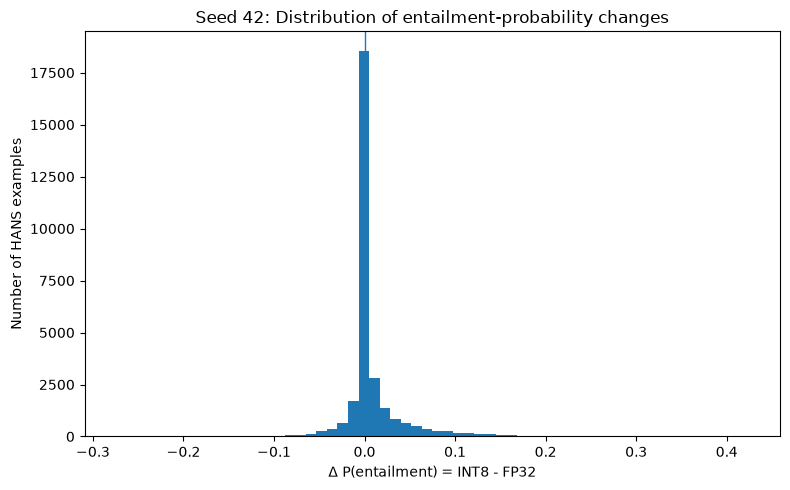

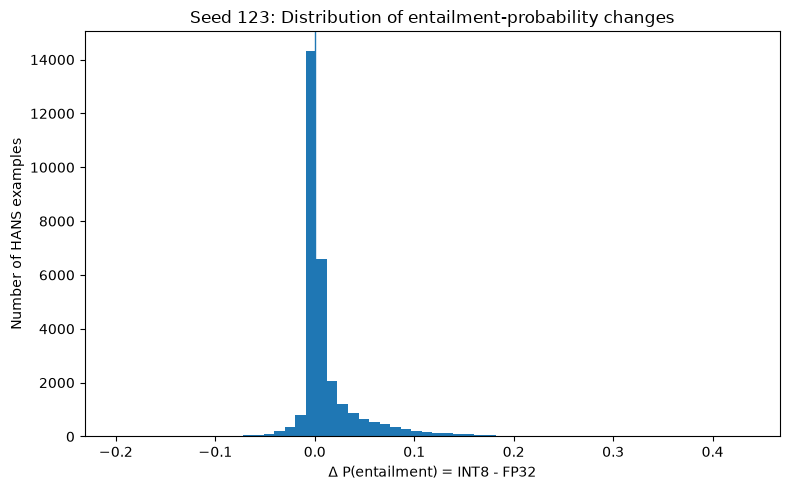

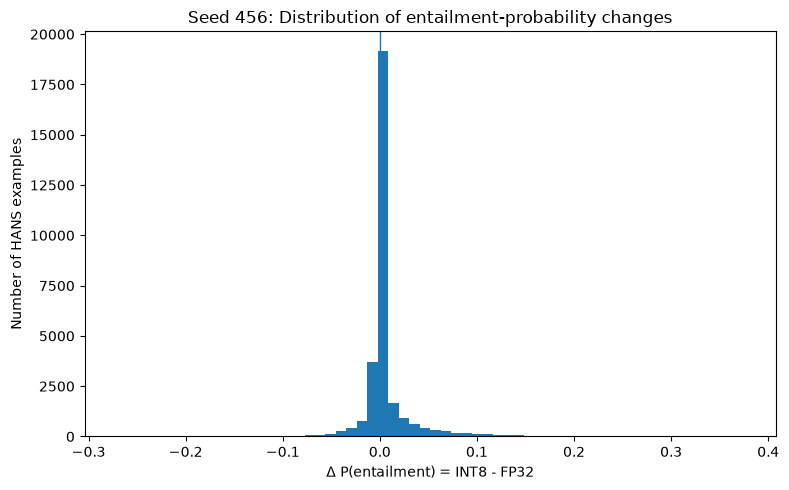

In [17]:
if not paired.empty:
    for seed in sorted(paired["seed"].unique()):
        g = paired[paired["seed"] == seed]

        plt.figure(figsize=(8, 5))
        plt.hist(g["delta_prob_entailment"], bins=60)
        plt.axvline(0, linewidth=1)
        plt.xlabel("Δ P(entailment) = INT8 - FP32")
        plt.ylabel("Number of HANS examples")
        plt.title(f"Seed {seed}: Distribution of entailment-probability changes")
        plt.tight_layout()
        plt.show()

## 18. Probability changes by heuristic and gold label

These boxplots help reveal whether one HANS category experiences systematically different probability movement after quantization.

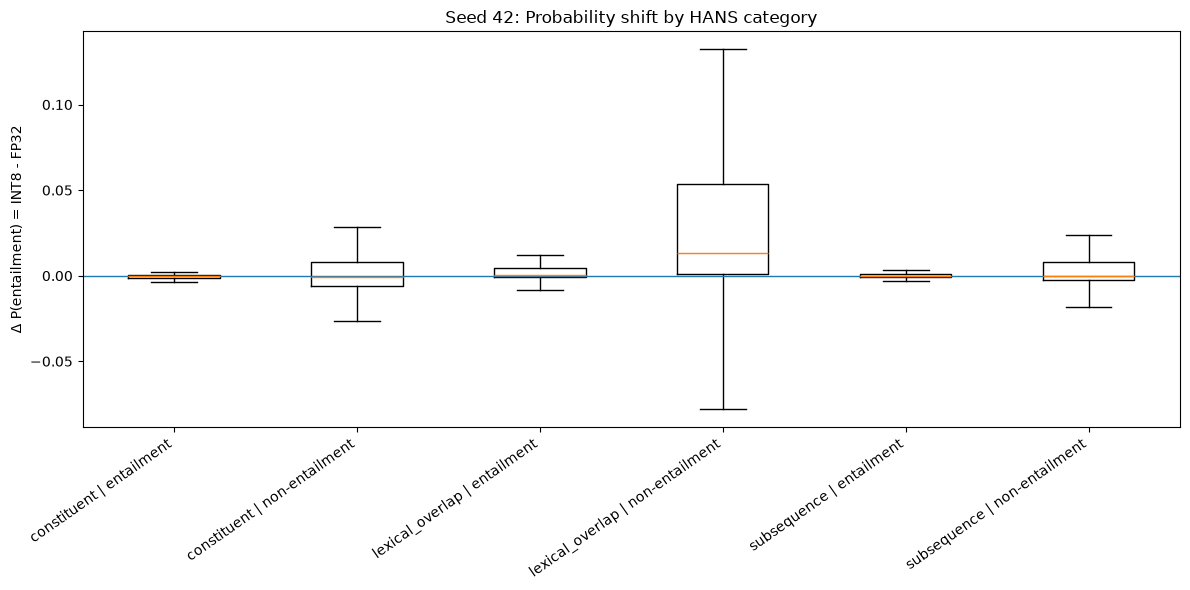

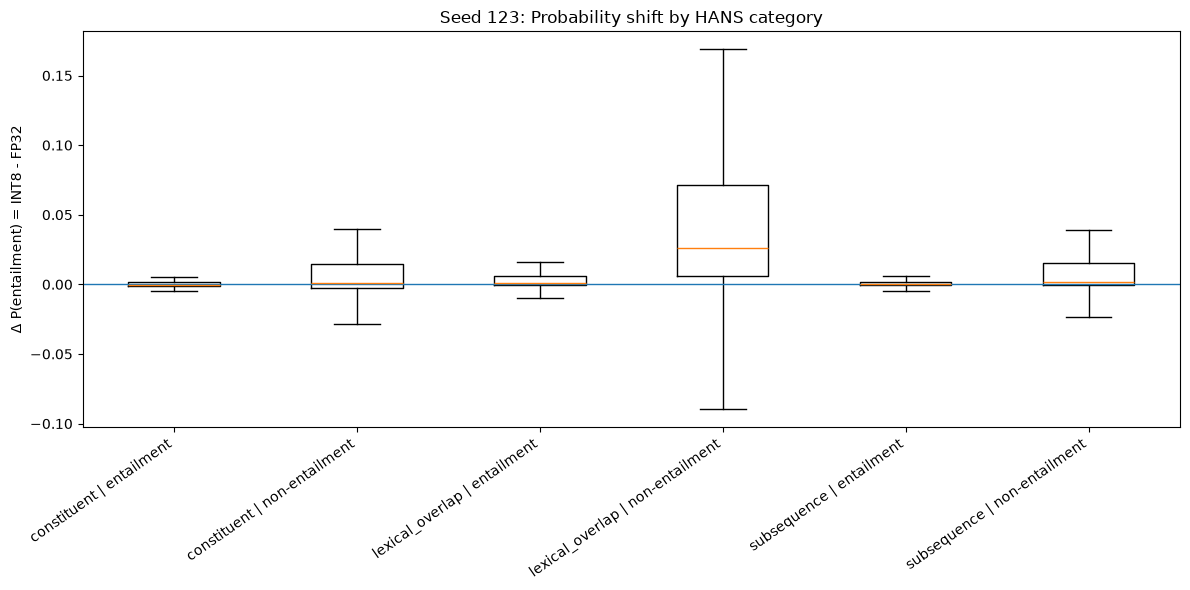

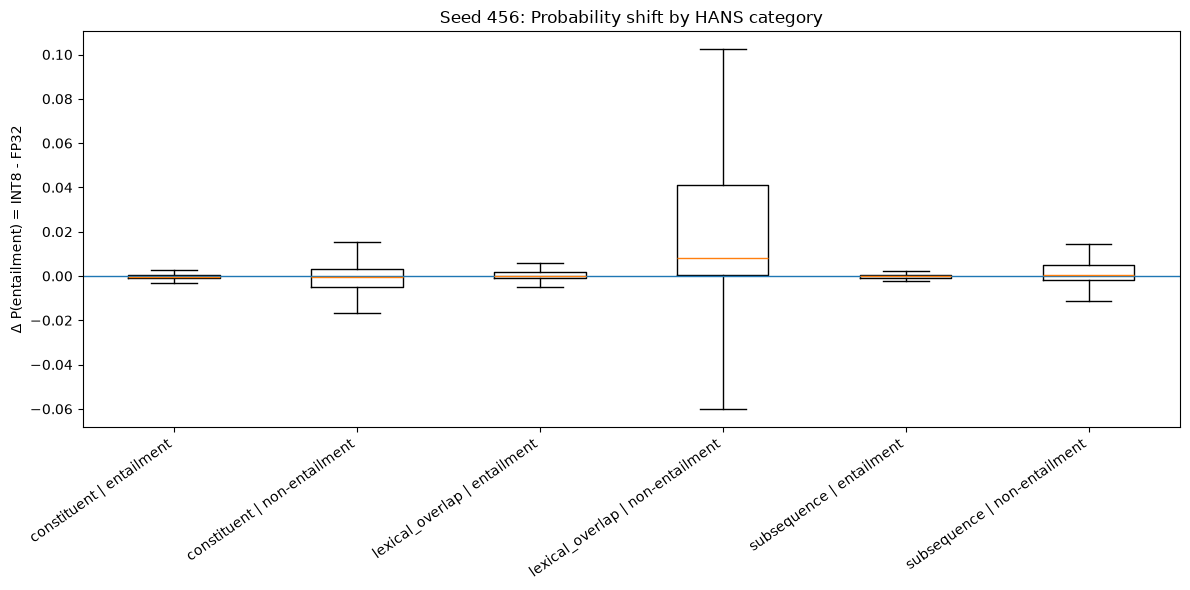

In [18]:
if not paired.empty:
    categories = (
        paired["heuristic"].astype(str)
        + " | "
        + paired["gold_label"].astype(str)
    )
    temp = paired.assign(category=categories)

    for seed in sorted(temp["seed"].unique()):
        g = temp[temp["seed"] == seed]
        order = sorted(g["category"].unique())
        data = [
            g.loc[g["category"] == category, "delta_prob_entailment"].dropna().values
            for category in order
        ]

        plt.figure(figsize=(12, 6))
        plt.boxplot(data, tick_labels=order, showfliers=False)
        plt.axhline(0, linewidth=1)
        plt.ylabel("Δ P(entailment) = INT8 - FP32")
        plt.title(f"Seed {seed}: Probability shift by HANS category")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

## 19. Changed confidence without a prediction flip

This isolates examples where FP32 and INT8 make the **same binary prediction**, but quantization substantially changes the probability distribution.

The threshold below is exploratory and can be changed. It is **not** a statistical significance threshold.

In [19]:
PROB_SHIFT_THRESHOLD = 0.10

if not paired.empty:
    confidence_shift_no_flip = paired[
        (~paired["prediction_flip"])
        & (paired["delta_prob_entailment"].abs() >= PROB_SHIFT_THRESHOLD)
    ].copy()

    confidence_shift_no_flip = confidence_shift_no_flip.sort_values(
        "delta_prob_entailment",
        key=lambda s: s.abs(),
        ascending=False
    )

    cols = [
        "seed", "pairID", "heuristic", "gold_label", "subcase",
        "hans_prediction_fp32", "hans_prediction_int8",
        "prob_entailment_fp32", "prob_entailment_int8",
        "delta_prob_entailment",
        "prob_gold_fp32", "prob_gold_int8", "delta_prob_gold",
    ]
    if "premise" in confidence_shift_no_flip.columns:
        cols += ["premise", "hypothesis"]

    display(confidence_shift_no_flip[cols].head(50))
    save_table(
        confidence_shift_no_flip,
        "large_probability_shifts_without_prediction_flip.csv"
    )

,seed,pairID,heuristic,gold_label,subcase,hans_prediction_fp32,hans_prediction_int8,prob_entailment_fp32,prob_entailment_int8,delta_prob_entailment,prob_gold_fp32,prob_gold_int8,delta_prob_gold,premise,hypothesis
31660,123,ex1660,lexical_overlap,non-entailment,ln_preposition,non-entailment,non-entailment,0.139940,0.468223,0.328284,0.860060,0.531777,-0.328284,The actors behind the athletes called the scie...,The scientists called the actors .
808,42,ex808,lexical_overlap,non-entailment,ln_subject/object_swap,entailment,entailment,0.542409,0.863237,0.320828,0.457591,0.136763,-0.320828,The doctors stopped the scientists .,The scientists stopped the doctors .
60315,456,ex315,lexical_overlap,non-entailment,ln_subject/object_swap,entailment,entailment,0.503619,0.815061,0.311442,0.496381,0.184939,-0.311442,The manager introduced the athletes .,The athletes introduced the manager .
2470,42,ex2470,lexical_overlap,non-entailment,ln_relative_clause,entailment,entailment,0.497836,0.807184,0.309347,0.502163,0.192816,-0.309347,The doctor supported the senator that the prof...,The senator supported the doctor .
62174,456,ex2174,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,non-entailment,0.119177,0.419996,0.300820,0.880824,0.580004,-0.300820,The bankers who encouraged the artist called t...,The artist called the bankers .
11293,42,ex11293,subsequence,non-entailment,sn_PP_on_subject,entailment,entailment,0.520881,0.812504,0.291623,0.479119,0.187496,-0.291623,The scientists next to the lawyer shouted .,The lawyer shouted .
11316,42,ex11316,subsequence,non-entailment,sn_PP_on_subject,non-entailment,non-entailment,0.154568,0.445473,0.290905,0.845432,0.554527,-0.290905,The manager behind the senator performed .,The senator performed .
730,42,ex730,lexical_overlap,non-entailment,ln_subject/object_swap,entailment,entailment,0.542406,0.831601,0.289194,0.457594,0.168399,-0.289194,The authors mentioned the professors .,The professors mentioned the authors .
809,42,ex809,lexical_overlap,non-entailment,ln_subject/object_swap,entailment,entailment,0.575093,0.862173,0.287079,0.424907,0.137827,-0.287079,The professor recognized the student .,The student recognized the professor .
31851,123,ex1851,lexical_overlap,non-entailment,ln_preposition,non-entailment,non-entailment,0.139815,0.425514,0.285699,0.860185,0.574486,-0.285699,The students near the doctor called the scient...,The scientists called the students .


Saved: ../results/hans/paired_fp32_int8/large_probability_shifts_without_prediction_flip.csv


## 20. Largest harmful and beneficial probability changes

Here “harmful” means probability assigned to the **gold HANS label decreased** after quantization; “beneficial” means it increased.

In [20]:
if not paired.empty:
    example_cols = [
        "seed", "pairID", "heuristic", "gold_label", "subcase",
        "hans_prediction_fp32", "hans_prediction_int8",
        "correct_fp32", "correct_int8",
        "prob_gold_fp32", "prob_gold_int8", "delta_prob_gold",
    ]
    if "premise" in paired.columns:
        example_cols += ["premise", "hypothesis"]

    print("Largest decreases in probability assigned to the gold label:")
    display(
        paired.nsmallest(25, "delta_prob_gold")[example_cols]
    )

    print("Largest increases in probability assigned to the gold label:")
    display(
        paired.nlargest(25, "delta_prob_gold")[example_cols]
    )

Largest decreases in probability assigned to the gold label:


,seed,pairID,heuristic,gold_label,subcase,hans_prediction_fp32,hans_prediction_int8,correct_fp32,correct_int8,prob_gold_fp32,prob_gold_int8,delta_prob_gold,premise,hypothesis
31705,123,ex1705,lexical_overlap,non-entailment,ln_preposition,non-entailment,entailment,True,False,0.699419,0.263406,-0.436014,The banker stopped the author behind the artist .,The author stopped the banker .
2998,42,ex2998,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,entailment,True,False,0.628665,0.204726,-0.423939,The doctor saw the scientist who helped the pr...,The professor saw the doctor .
916,42,ex916,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.777811,0.394757,-0.383054,The tourist called the students .,The students called the tourist .
62606,456,ex2606,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,entailment,True,False,0.744845,0.369345,-0.375500,The professor that supported the tourist recom...,The judge recommended the professor .
41871,123,ex11871,subsequence,non-entailment,sn_PP_on_subject,non-entailment,entailment,True,False,0.866905,0.496165,-0.370740,The judges in front of the senator recommended...,The senator recommended the tourist .
14607,42,ex14607,subsequence,non-entailment,sn_NP/Z,non-entailment,entailment,True,False,0.560084,0.191051,-0.369033,Since the judges fought the scientists resigned .,The judges fought the scientists .
32767,123,ex2767,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,entailment,True,False,0.657775,0.290235,-0.367540,The professor thanked the doctor who the athle...,The athletes thanked the professor .
30735,123,ex735,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.729966,0.376412,-0.353554,The doctor recommended the senator .,The senator recommended the doctor .
11004,42,ex11004,subsequence,non-entailment,sn_PP_on_subject,non-entailment,entailment,True,False,0.596956,0.264608,-0.332349,The judges next to the senator called the stud...,The senator called the students .
31660,123,ex1660,lexical_overlap,non-entailment,ln_preposition,non-entailment,non-entailment,True,True,0.860060,0.531777,-0.328284,The actors behind the athletes called the scie...,The scientists called the actors .


Largest increases in probability assigned to the gold label:


,seed,pairID,heuristic,gold_label,subcase,hans_prediction_fp32,hans_prediction_int8,correct_fp32,correct_int8,prob_gold_fp32,prob_gold_int8,delta_prob_gold,premise,hypothesis
68757,456,ex8757,lexical_overlap,entailment,le_conjunction,non-entailment,entailment,False,True,0.397159,0.715265,0.318106,The tourist called the doctor and the bankers .,The tourist called the bankers .
5333,42,ex5333,lexical_overlap,entailment,le_relative_clause,non-entailment,entailment,False,True,0.489311,0.775864,0.286552,The students that the senator contacted called...,The senator contacted the students .
5562,42,ex5562,lexical_overlap,entailment,le_relative_clause,non-entailment,entailment,False,True,0.468418,0.753076,0.284657,The secretary who the manager recommended ment...,The manager recommended the secretary .
376,42,ex376,lexical_overlap,non-entailment,ln_subject/object_swap,entailment,non-entailment,False,True,0.350930,0.625160,0.274230,The scientists believed the actor .,The actor believed the scientists .
5351,42,ex5351,lexical_overlap,entailment,le_relative_clause,non-entailment,non-entailment,False,False,0.211561,0.474598,0.263037,The doctors advised the professor who encourag...,The professor encouraged the artist .
38961,123,ex8961,lexical_overlap,entailment,le_conjunction,entailment,entailment,True,True,0.576808,0.835034,0.258226,The banker thanked the judges and the doctor .,The banker thanked the doctor .
62484,456,ex2484,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,non-entailment,True,True,0.637951,0.882410,0.244459,The doctors who the athletes avoided believed ...,The artist believed the doctors .
1930,42,ex1930,lexical_overlap,non-entailment,ln_preposition,entailment,entailment,False,False,0.130501,0.374034,0.243533,The author behind the doctor admired the stude...,The students admired the author .
64026,456,ex4026,lexical_overlap,non-entailment,ln_conjunction,entailment,non-entailment,False,True,0.431952,0.673843,0.241891,The judges and the tourists avoided the student .,The judges avoided the tourists .
61635,456,ex1635,lexical_overlap,non-entailment,ln_preposition,entailment,non-entailment,False,True,0.338198,0.571091,0.232893,The athlete recommended the actor by the stude...,The students recommended the athlete .


# Part C — Paired Statistical Analysis

## 21. McNemar's exact test for paired accuracy

For the same HANS examples, define:

- \(b\): FP32 correct → INT8 wrong
- \(c\): FP32 wrong → INT8 correct

Under the null hypothesis that neither representation is systematically more likely to be correct, the discordant outcomes are symmetric.

The exact McNemar test can therefore be computed as a two-sided binomial test on \(b\) vs \(c\).

**Important:** statistical significance does not tell us whether an effect is practically meaningful. Always inspect the actual accuracy difference and effect consistency across seeds.

In [21]:
def mcnemar_exact(df):
    b = int(df["correct_to_wrong"].sum())
    c = int(df["wrong_to_correct"].sum())
    discordant = b + c

    if discordant == 0:
        p_value = 1.0
    elif SCIPY_AVAILABLE:
        p_value = binomtest(
            min(b, c),
            n=discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue
    else:
        p_value = np.nan

    return {
        "n": len(df),
        "correct_to_wrong": b,
        "wrong_to_correct": c,
        "discordant": discordant,
        "delta_accuracy": df["correct_int8"].mean() - df["correct_fp32"].mean(),
        "p_value": p_value,
    }


if not paired.empty:
    mcnemar_rows = []

    for seed, g in paired.groupby("seed"):
        result = mcnemar_exact(g)
        result["seed"] = seed
        result["group"] = "overall"
        mcnemar_rows.append(result)

        for (heuristic, gold_label), sub in g.groupby(
            ["heuristic", "gold_label"], observed=False
        ):
            result = mcnemar_exact(sub)
            result["seed"] = seed
            result["group"] = f"{heuristic} | {gold_label}"
            mcnemar_rows.append(result)

    mcnemar_results = pd.DataFrame(mcnemar_rows)[
        [
            "seed", "group", "n",
            "correct_to_wrong", "wrong_to_correct", "discordant",
            "delta_accuracy", "p_value"
        ]
    ]

    display(mcnemar_results)
    save_table(mcnemar_results, "mcnemar_exact_tests.csv")

,seed,group,n,correct_to_wrong,wrong_to_correct,discordant,delta_accuracy,p_value
0,42,overall,30000,375,143,518,-0.007733,5.187213e-25
1,42,constituent | entailment,5000,1,15,16,0.002800,5.187988e-04
2,42,constituent | non-entailment,5000,69,46,115,-0.004600,3.975051e-02
3,42,lexical_overlap | entailment,5000,9,41,50,0.006400,5.614100e-06
4,42,lexical_overlap | non-entailment,5000,216,21,237,-0.039000,5.832048e-42
5,42,subsequence | entailment,5000,0,6,6,0.001200,3.125000e-02
6,42,subsequence | non-entailment,5000,80,14,94,-0.013200,2.120124e-12
7,123,overall,30000,450,79,529,-0.012367,4.743892e-64
8,123,constituent | entailment,5000,2,5,7,0.000600,4.531250e-01
9,123,constituent | non-entailment,5000,75,22,97,-0.010600,6.073393e-08


Saved: ../results/hans/paired_fp32_int8/mcnemar_exact_tests.csv


## 22. Bootstrap confidence intervals for paired accuracy change

For each seed/group, we resample **paired examples** with replacement and recompute:

\[
\Delta Accuracy = Accuracy_{INT8} - Accuracy_{FP32}
\]

The 2.5th and 97.5th percentiles give an empirical 95% bootstrap interval.

This preserves the paired structure because each resampled unit contains both FP32 and INT8 outcomes for the same HANS example.

In [22]:
BOOTSTRAP_SAMPLES = 5000
BOOTSTRAP_RANDOM_SEED = 2026

def bootstrap_delta_accuracy(
    df,
    n_boot=BOOTSTRAP_SAMPLES,
    random_seed=BOOTSTRAP_RANDOM_SEED
):
    rng = np.random.default_rng(random_seed)

    diffs = (
        df["correct_int8"].astype(float).to_numpy()
        - df["correct_fp32"].astype(float).to_numpy()
    )

    n = len(diffs)
    observed = diffs.mean()

    boot = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[i] = diffs[idx].mean()

    low, high = np.quantile(boot, [0.025, 0.975])

    return {
        "delta_accuracy": observed,
        "ci95_low": low,
        "ci95_high": high,
    }


if not paired.empty:
    bootstrap_rows = []

    for seed, g in paired.groupby("seed"):
        result = bootstrap_delta_accuracy(g, random_seed=BOOTSTRAP_RANDOM_SEED + int(seed))
        result.update({"seed": seed, "group": "overall", "n": len(g)})
        bootstrap_rows.append(result)

        for j, ((heuristic, gold_label), sub) in enumerate(
            g.groupby(["heuristic", "gold_label"], observed=False)
        ):
            result = bootstrap_delta_accuracy(
                sub,
                random_seed=BOOTSTRAP_RANDOM_SEED + int(seed) + j + 1
            )
            result.update({
                "seed": seed,
                "group": f"{heuristic} | {gold_label}",
                "n": len(sub)
            })
            bootstrap_rows.append(result)

    bootstrap_results = pd.DataFrame(bootstrap_rows)
    display(bootstrap_results)
    save_table(bootstrap_results, "bootstrap_delta_accuracy_ci.csv")

,delta_accuracy,ci95_low,ci95_high,seed,group,n
0,-0.007733,-0.009168,-0.006267,42,overall,30000
1,0.002800,0.001400,0.004400,42,constituent | entailment,5000
2,-0.004600,-0.008600,-0.000595,42,constituent | non-entailment,5000
3,0.006400,0.003800,0.009200,42,lexical_overlap | entailment,5000
4,-0.039000,-0.045000,-0.033200,42,lexical_overlap | non-entailment,5000
5,0.001200,0.000400,0.002200,42,subsequence | entailment,5000
6,-0.013200,-0.017000,-0.009400,42,subsequence | non-entailment,5000
7,-0.012367,-0.013900,-0.010900,123,overall,30000
8,0.000600,-0.000400,0.001600,123,constituent | entailment,5000
9,-0.010600,-0.014400,-0.006800,123,constituent | non-entailment,5000


Saved: ../results/hans/paired_fp32_int8/bootstrap_delta_accuracy_ci.csv


## 23. Wilcoxon signed-rank tests for paired probability shifts

For probability changes, we can test whether the paired shift distribution is centered around zero.

We report:
- shift in \(P(entailment)\);
- shift in probability assigned to the **gold HANS label**.

The Wilcoxon signed-rank test is non-parametric and does not assume normally distributed probability differences.

Again, use p-values together with effect sizes/distributions rather than as the sole conclusion.

In [23]:
def wilcoxon_summary(df, delta_col):
    x = df[delta_col].dropna().to_numpy()

    if len(x) == 0:
        return {
            "n": 0, "mean_delta": np.nan, "median_delta": np.nan,
            "mean_abs_delta": np.nan, "statistic": np.nan, "p_value": np.nan
        }

    if SCIPY_AVAILABLE and not np.allclose(x, 0):
        test = wilcoxon(x, alternative="two-sided", zero_method="wilcox")
        statistic = test.statistic
        p_value = test.pvalue
    else:
        statistic = np.nan
        p_value = 1.0 if np.allclose(x, 0) else np.nan

    return {
        "n": len(x),
        "mean_delta": x.mean(),
        "median_delta": np.median(x),
        "mean_abs_delta": np.abs(x).mean(),
        "statistic": statistic,
        "p_value": p_value,
    }


if not paired.empty:
    wilcoxon_rows = []

    for seed, g in paired.groupby("seed"):
        for metric in ["delta_prob_entailment", "delta_prob_gold"]:
            result = wilcoxon_summary(g, metric)
            result.update({
                "seed": seed,
                "group": "overall",
                "metric": metric,
            })
            wilcoxon_rows.append(result)

        for (heuristic, gold_label), sub in g.groupby(
            ["heuristic", "gold_label"], observed=False
        ):
            for metric in ["delta_prob_entailment", "delta_prob_gold"]:
                result = wilcoxon_summary(sub, metric)
                result.update({
                    "seed": seed,
                    "group": f"{heuristic} | {gold_label}",
                    "metric": metric,
                })
                wilcoxon_rows.append(result)

    wilcoxon_results = pd.DataFrame(wilcoxon_rows)
    display(wilcoxon_results)
    save_table(wilcoxon_results, "wilcoxon_probability_shift_tests.csv")

,n,mean_delta,median_delta,mean_abs_delta,statistic,p_value,seed,group,metric
0,30000,0.008839,-0.000043,0.015987,187966355.0,1.256686e-134,42,overall,delta_prob_entailment
1,30000,-0.006012,-0.000251,0.015987,191085317.0,3.140089e-113,42,overall,delta_prob_gold
2,5000,-0.000370,-0.000398,0.004330,4075849.0,8.919767e-101,42,constituent | entailment,delta_prob_entailment
3,5000,-0.000370,-0.000398,0.004330,4075849.0,8.919767e-101,42,constituent | entailment,delta_prob_gold
4,5000,0.002127,-0.000539,0.016376,6082516.0,9.833069e-02,42,constituent | non-entailment,delta_prob_entailment
5,5000,-0.002127,0.000539,0.016376,6082519.0,9.833667e-02,42,constituent | non-entailment,delta_prob_gold
6,5000,0.006562,0.000197,0.011366,4673814.0,7.163864e-54,42,lexical_overlap | entailment,delta_prob_entailment
7,5000,0.006562,0.000197,0.011366,4673814.0,7.163864e-54,42,lexical_overlap | entailment,delta_prob_gold
8,5000,0.032492,0.013336,0.041097,1870161.0,0.000000e+00,42,lexical_overlap | non-entailment,delta_prob_entailment
9,5000,-0.032492,-0.013336,0.041097,1870160.0,0.000000e+00,42,lexical_overlap | non-entailment,delta_prob_gold


Saved: ../results/hans/paired_fp32_int8/wilcoxon_probability_shift_tests.csv


# Part D — Across-Seed Consistency

## 24. Mean ± SD across the three model seeds

The seed is the model-level replicate. We therefore summarize per-seed effects rather than treating all 90,000 HANS rows as independent model replicates.

This section becomes most useful once all three INT8 files are available.

In [24]:
def across_seed_summary(per_seed_df, group_cols, metric_cols):
    agg_spec = {}
    for metric in metric_cols:
        agg_spec[f"{metric}_mean"] = (metric, "mean")
        agg_spec[f"{metric}_sd"] = (metric, "std")
        agg_spec[f"{metric}_min"] = (metric, "min")
        agg_spec[f"{metric}_max"] = (metric, "max")

    out = (
        per_seed_df
        .groupby(group_cols, dropna=False, observed=False)
        .agg(**agg_spec)
        .reset_index()
    )
    out["num_seeds"] = (
        per_seed_df.groupby(group_cols, dropna=False, observed=False)
        .size()
        .values
    )
    return out


if not paired.empty:
    seed_level = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    )

    across_seeds = across_seed_summary(
        seed_level,
        ["heuristic", "gold_label"],
        ["fp32_accuracy", "int8_accuracy", "delta_accuracy", "flip_rate"]
    )

    display(across_seeds)
    save_table(across_seeds, "across_seed_heuristic_gold_label_summary.csv")

,heuristic,gold_label,fp32_accuracy_mean,fp32_accuracy_sd,fp32_accuracy_min,fp32_accuracy_max,int8_accuracy_mean,int8_accuracy_sd,int8_accuracy_min,int8_accuracy_max,delta_accuracy_mean,delta_accuracy_sd,delta_accuracy_min,delta_accuracy_max,flip_rate_mean,flip_rate_sd,flip_rate_min,flip_rate_max,num_seeds
0,constituent,entailment,0.995467,0.003580,0.9924,0.9994,0.996667,0.002540,0.9952,0.9996,0.001200,0.001400,0.0002,0.0028,0.001867,0.001172,0.0010,0.0032,3
1,constituent,non-entailment,0.103200,0.049410,0.0474,0.1414,0.096800,0.048120,0.0434,0.1368,-0.006400,0.003650,-0.0106,-0.0040,0.018400,0.005173,0.0128,0.0230,3
2,lexical_overlap,entailment,0.967200,0.017143,0.9476,0.9794,0.972067,0.016078,0.9540,0.9848,0.004867,0.001858,0.0028,0.0064,0.007533,0.002194,0.0058,0.0100,3
3,lexical_overlap,non-entailment,0.357600,0.145945,0.1898,0.4550,0.314400,0.135494,0.1580,0.3962,-0.043200,0.013981,-0.0588,-0.0318,0.049600,0.011854,0.0390,0.0624,3
4,subsequence,entailment,0.995267,0.001474,0.9936,0.9964,0.996667,0.001617,0.9948,0.9976,0.001400,0.000346,0.0012,0.0018,0.001400,0.000346,0.0012,0.0018,3
5,subsequence,non-entailment,0.055200,0.028374,0.0238,0.0790,0.045733,0.023022,0.0206,0.0658,-0.009467,0.005460,-0.0132,-0.0032,0.014000,0.005769,0.0076,0.0188,3


Saved: ../results/hans/paired_fp32_int8/across_seed_heuristic_gold_label_summary.csv


## 25. Visualize accuracy change across seeds

A consistent effect should generally point in the same direction across the independently trained seeds.

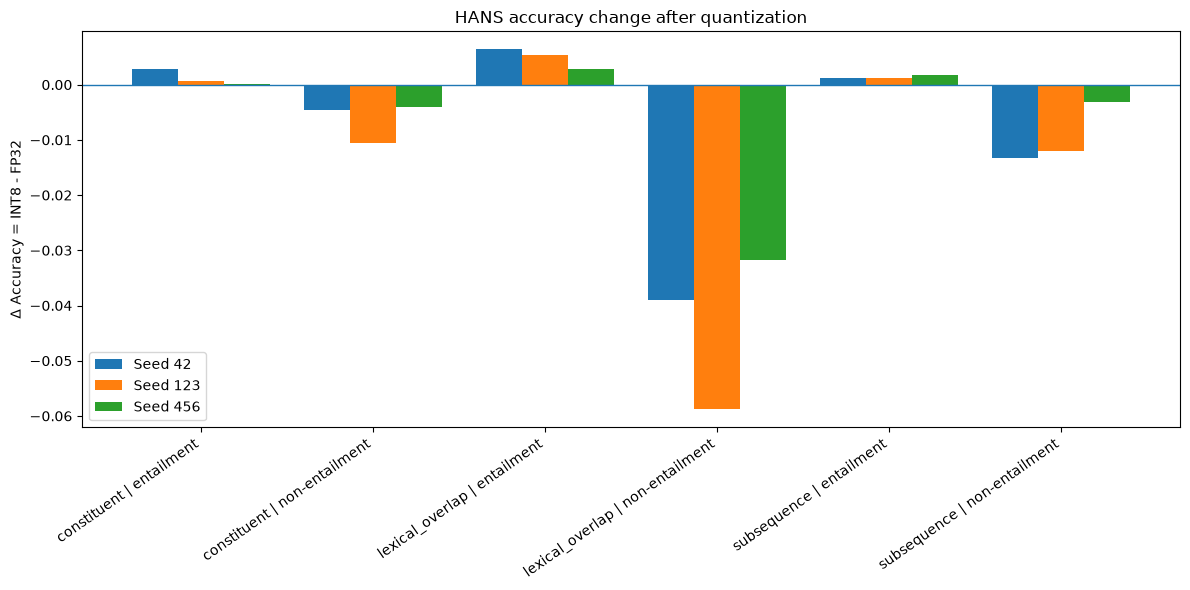

In [25]:
if not paired.empty:
    plot_df = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    ).copy()

    plot_df["category"] = (
        plot_df["heuristic"].astype(str)
        + " | "
        + plot_df["gold_label"].astype(str)
    )

    categories = sorted(plot_df["category"].unique())
    seeds = sorted(plot_df["seed"].unique())

    x = np.arange(len(categories))
    width = 0.8 / max(len(seeds), 1)

    plt.figure(figsize=(12, 6))

    for i, seed in enumerate(seeds):
        s = (
            plot_df[plot_df["seed"] == seed]
            .set_index("category")
            .reindex(categories)
        )
        offset = (i - (len(seeds) - 1) / 2) * width
        plt.bar(
            x + offset,
            s["delta_accuracy"].values,
            width=width,
            label=f"Seed {seed}"
        )

    plt.axhline(0, linewidth=1)
    plt.xticks(x, categories, rotation=35, ha="right")
    plt.ylabel("Δ Accuracy = INT8 - FP32")
    plt.title("HANS accuracy change after quantization")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Part E — Example-Level Inspection

## 26. Inspect prediction flips

These rows are useful for qualitative analysis after the quantitative patterns are known.

In [26]:
if not paired.empty:
    flipped = paired[paired["prediction_flip"]].copy()

    flip_cols = [
        "seed", "pairID", "heuristic", "gold_label", "subcase",
        "hans_prediction_fp32", "hans_prediction_int8",
        "correct_fp32", "correct_int8",
        "prob_entailment_fp32", "prob_entailment_int8",
        "delta_prob_entailment",
        "prob_gold_fp32", "prob_gold_int8", "delta_prob_gold",
    ]

    if "premise" in flipped.columns:
        flip_cols += ["premise", "hypothesis"]

    print("Total paired prediction flips:", len(flipped))
    display(flipped[flip_cols].head(100))
    save_table(flipped, "all_prediction_flips.csv")

Total paired prediction flips: 1392


,seed,pairID,heuristic,gold_label,subcase,hans_prediction_fp32,hans_prediction_int8,correct_fp32,correct_int8,prob_entailment_fp32,prob_entailment_int8,delta_prob_entailment,prob_gold_fp32,prob_gold_int8,delta_prob_gold,premise,hypothesis
1,42,ex1,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.400045,0.495494,0.095449,0.599955,0.504506,-0.095449,The student saw the managers .,The managers saw the student .
4,42,ex4,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.389890,0.595560,0.205670,0.610110,0.404440,-0.205670,The actors avoided the bankers .,The bankers avoided the actors .
26,42,ex26,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.386162,0.621738,0.235576,0.613838,0.378262,-0.235576,The authors recommended the professors .,The professors recommended the authors .
29,42,ex29,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.319299,0.611226,0.291927,0.680701,0.388774,-0.291927,The authors introduced the students .,The students introduced the authors .
32,42,ex32,lexical_overlap,non-entailment,ln_subject/object_swap,entailment,non-entailment,False,True,0.506014,0.357393,-0.148621,0.493986,0.642607,0.148621,The students believed the judges .,The judges believed the students .
45,42,ex45,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.299817,0.509257,0.209440,0.700183,0.490743,-0.209440,The presidents contacted the scientist .,The scientist contacted the presidents .
48,42,ex48,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.491547,0.635820,0.144273,0.508453,0.364180,-0.144273,The student contacted the senator .,The senator contacted the student .
62,42,ex62,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.456231,0.657975,0.201744,0.543769,0.342025,-0.201744,The actors called the professor .,The professor called the actors .
83,42,ex83,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.468759,0.653086,0.184327,0.531241,0.346914,-0.184327,The doctor encouraged the author .,The author encouraged the doctor .
111,42,ex111,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,True,False,0.410678,0.610204,0.199527,0.589322,0.389795,-0.199527,The doctors mentioned the professors .,The professors mentioned the doctors .


Saved: ../results/hans/paired_fp32_int8/all_prediction_flips.csv


## 27. Most harmful C→W examples

This is a focused qualitative sample: examples that FP32 handled correctly but INT8 misclassified.

In [27]:
if not paired.empty:
    harmful = paired[paired["correct_to_wrong"]].copy()
    harmful = harmful.sort_values("delta_prob_gold")

    harmful_cols = [
        "seed", "pairID", "heuristic", "gold_label", "subcase",
        "hans_prediction_fp32", "hans_prediction_int8",
        "prob_gold_fp32", "prob_gold_int8", "delta_prob_gold",
    ]
    if "premise" in harmful.columns:
        harmful_cols += ["premise", "hypothesis"]

    display(harmful[harmful_cols].head(50))
    save_table(harmful, "correct_to_wrong_examples.csv")

,seed,pairID,heuristic,gold_label,subcase,hans_prediction_fp32,hans_prediction_int8,prob_gold_fp32,prob_gold_int8,delta_prob_gold,premise,hypothesis
31705,123,ex1705,lexical_overlap,non-entailment,ln_preposition,non-entailment,entailment,0.699419,0.263406,-0.436014,The banker stopped the author behind the artist .,The author stopped the banker .
2998,42,ex2998,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,entailment,0.628665,0.204726,-0.423939,The doctor saw the scientist who helped the pr...,The professor saw the doctor .
916,42,ex916,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,0.777811,0.394757,-0.383054,The tourist called the students .,The students called the tourist .
62606,456,ex2606,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,entailment,0.744845,0.369345,-0.375500,The professor that supported the tourist recom...,The judge recommended the professor .
41871,123,ex11871,subsequence,non-entailment,sn_PP_on_subject,non-entailment,entailment,0.866905,0.496165,-0.370740,The judges in front of the senator recommended...,The senator recommended the tourist .
14607,42,ex14607,subsequence,non-entailment,sn_NP/Z,non-entailment,entailment,0.560084,0.191051,-0.369033,Since the judges fought the scientists resigned .,The judges fought the scientists .
32767,123,ex2767,lexical_overlap,non-entailment,ln_relative_clause,non-entailment,entailment,0.657775,0.290235,-0.367540,The professor thanked the doctor who the athle...,The athletes thanked the professor .
30735,123,ex735,lexical_overlap,non-entailment,ln_subject/object_swap,non-entailment,entailment,0.729966,0.376412,-0.353554,The doctor recommended the senator .,The senator recommended the doctor .
11004,42,ex11004,subsequence,non-entailment,sn_PP_on_subject,non-entailment,entailment,0.596956,0.264608,-0.332349,The judges next to the senator called the stud...,The senator called the students .
64699,456,ex4699,lexical_overlap,non-entailment,ln_conjunction,non-entailment,entailment,0.773245,0.448595,-0.324650,The managers and the scientists avoided the au...,The managers avoided the scientists .


Saved: ../results/hans/paired_fp32_int8/correct_to_wrong_examples.csv


# Part F — Final Results Dashboard

## 28. Compact tables for deciding what belongs in the final report

This section intentionally does not decide the scientific conclusion for you. It collects the strongest candidate results so you can inspect:
- magnitude;
- direction;
- consistency across seeds;
- paired significance/uncertainty;
- probability movement;
- qualitative examples.

In [28]:
if not paired.empty:
    print("=== OVERALL BY SEED ===")
    display(accuracy_summary(paired, ["seed"]))

    print("\n=== HEURISTIC × GOLD LABEL BY SEED ===")
    display(
        accuracy_summary(
            paired,
            ["seed", "heuristic", "gold_label"]
        )
    )

    print("\n=== PROBABILITY SHIFTS ===")
    display(
        probability_summary(
            paired,
            ["seed", "heuristic", "gold_label"]
        )
    )

    if "mcnemar_results" in globals():
        print("\n=== MCNEMAR EXACT TESTS ===")
        display(mcnemar_results)

    if "bootstrap_results" in globals():
        print("\n=== BOOTSTRAP 95% CIs ===")
        display(bootstrap_results)

    if "wilcoxon_results" in globals():
        print("\n=== WILCOXON PROBABILITY TESTS ===")
        display(wilcoxon_results)

=== OVERALL BY SEED ===


,seed,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
0,42,30000,0.597000,0.589267,-0.007733,518,0.017267,375,143
1,123,30000,0.601500,0.589133,-0.012367,529,0.017633,450,79
2,456,30000,0.538467,0.532767,-0.005700,345,0.011500,258,87



=== HEURISTIC × GOLD LABEL BY SEED ===


,seed,heuristic,gold_label,n,fp32_accuracy,int8_accuracy,delta_accuracy,flip_count,flip_rate,correct_to_wrong,wrong_to_correct
0,42,constituent,entailment,5000,0.9924,0.9952,0.0028,16,0.0032,1,15
1,42,constituent,non-entailment,5000,0.1414,0.1368,-0.0046,115,0.0230,69,46
2,42,lexical_overlap,entailment,5000,0.9476,0.9540,0.0064,50,0.0100,9,41
3,42,lexical_overlap,non-entailment,5000,0.4280,0.3890,-0.0390,237,0.0474,216,21
4,42,subsequence,entailment,5000,0.9936,0.9948,0.0012,6,0.0012,0,6
5,42,subsequence,non-entailment,5000,0.0790,0.0658,-0.0132,94,0.0188,80,14
6,123,constituent,entailment,5000,0.9946,0.9952,0.0006,7,0.0014,2,5
7,123,constituent,non-entailment,5000,0.1208,0.1102,-0.0106,97,0.0194,75,22
8,123,lexical_overlap,entailment,5000,0.9794,0.9848,0.0054,29,0.0058,1,28
9,123,lexical_overlap,non-entailment,5000,0.4550,0.3962,-0.0588,312,0.0624,303,9



=== PROBABILITY SHIFTS ===


...

,seed,group,n,correct_to_wrong,wrong_to_correct,discordant,delta_accuracy,p_value
0,42,overall,30000,375,143,518,-0.007733,5.187213e-25
1,42,constituent | entailment,5000,1,15,16,0.002800,5.187988e-04
2,42,constituent | non-entailment,5000,69,46,115,-0.004600,3.975051e-02
3,42,lexical_overlap | entailment,5000,9,41,50,0.006400,5.614100e-06
4,42,lexical_overlap | non-entailment,5000,216,21,237,-0.039000,5.832048e-42
5,42,subsequence | entailment,5000,0,6,6,0.001200,3.125000e-02
6,42,subsequence | non-entailment,5000,80,14,94,-0.013200,2.120124e-12
7,123,overall,30000,450,79,529,-0.012367,4.743892e-64
8,123,constituent | entailment,5000,2,5,7,0.000600,4.531250e-01
9,123,constituent | non-entailment,5000,75,22,97,-0.010600,6.073393e-08



=== BOOTSTRAP 95% CIs ===


,delta_accuracy,ci95_low,ci95_high,seed,group,n
0,-0.007733,-0.009168,-0.006267,42,overall,30000
1,0.002800,0.001400,0.004400,42,constituent | entailment,5000
2,-0.004600,-0.008600,-0.000595,42,constituent | non-entailment,5000
3,0.006400,0.003800,0.009200,42,lexical_overlap | entailment,5000
4,-0.039000,-0.045000,-0.033200,42,lexical_overlap | non-entailment,5000
5,0.001200,0.000400,0.002200,42,subsequence | entailment,5000
6,-0.013200,-0.017000,-0.009400,42,subsequence | non-entailment,5000
7,-0.012367,-0.013900,-0.010900,123,overall,30000
8,0.000600,-0.000400,0.001600,123,constituent | entailment,5000
9,-0.010600,-0.014400,-0.006800,123,constituent | non-entailment,5000



=== WILCOXON PROBABILITY TESTS ===


,n,mean_delta,median_delta,mean_abs_delta,statistic,p_value,seed,group,metric
0,30000,0.008839,-0.000043,0.015987,187966355.0,1.256686e-134,42,overall,delta_prob_entailment
1,30000,-0.006012,-0.000251,0.015987,191085317.0,3.140089e-113,42,overall,delta_prob_gold
2,5000,-0.000370,-0.000398,0.004330,4075849.0,8.919767e-101,42,constituent | entailment,delta_prob_entailment
3,5000,-0.000370,-0.000398,0.004330,4075849.0,8.919767e-101,42,constituent | entailment,delta_prob_gold
4,5000,0.002127,-0.000539,0.016376,6082516.0,9.833069e-02,42,constituent | non-entailment,delta_prob_entailment
5,5000,-0.002127,0.000539,0.016376,6082519.0,9.833667e-02,42,constituent | non-entailment,delta_prob_gold
6,5000,0.006562,0.000197,0.011366,4673814.0,7.163864e-54,42,lexical_overlap | entailment,delta_prob_entailment
7,5000,0.006562,0.000197,0.011366,4673814.0,7.163864e-54,42,lexical_overlap | entailment,delta_prob_gold
8,5000,0.032492,0.013336,0.041097,1870161.0,0.000000e+00,42,lexical_overlap | non-entailment,delta_prob_entailment
9,5000,-0.032492,-0.013336,0.041097,1870160.0,0.000000e+00,42,lexical_overlap | non-entailment,delta_prob_gold


## 29. Save the full paired dataset

This makes downstream plotting or report generation easy without repeating the merge.

In [29]:
if not paired.empty:
    paired_output = OUTPUT_DIR / "paired_fp32_int8_hans_all_seeds.csv"
    paired.to_csv(paired_output, index=False)
    print("Saved master paired dataset:", paired_output)

Saved master paired dataset: ../results/hans/paired_fp32_int8/paired_fp32_int8_hans_all_seeds.csv


# Interpretation checklist

When the INT8 predictions arrive, inspect the results in this order:

1. **Overall HANS Δ accuracy** for each seed.
2. **Entailment vs non-entailment** — determine whether aggregate accuracy hides asymmetric changes.
3. **Heuristic × gold label** — look for lexical-overlap, subsequence, or constituent-specific effects.
4. **Across-seed consistency** — prioritize patterns that repeat across independently trained seeds.
5. **Prediction flips** — compare C→W against W→C and identify where harmful flips concentrate.
6. **Probability movement** — check whether INT8 systematically shifts confidence even without prediction flips.
7. **McNemar + bootstrap CI** — quantify paired accuracy evidence and uncertainty.
8. **Wilcoxon + effect magnitude** — assess paired probability shifts, without treating p-values alone as the result.
9. **Subcases and example inspection** — use these to explain an observed aggregate pattern, not to search indefinitely for a favorable result.

### Important reporting principle

A small p-value is not sufficient evidence of an important behavioral change with 30,000 examples. Report the **effect size, direction, confidence interval, and consistency across seeds** alongside statistical tests.

Likewise, avoid pooling all three seeds and treating 90,000 rows as though they were 90,000 independent model runs. The examples are paired observations, while the three seeds are the independently trained model replicates.

# Part G — Publication-Style Visual Analysis

This section visualizes the most important paired FP32 → INT8 findings.

The figures are deliberately centered on **effect size and consistency across seeds**, rather than statistical significance alone.

### Visual questions
1. How small does the overall HANS change look compared with the hidden label-specific change?
2. Which heuristic × gold-label groups are most affected?
3. Are prediction flips mostly harmful (correct → wrong) or beneficial (wrong → correct)?
4. Does INT8 systematically shift probability toward entailment?
5. Are the largest effects consistent across all three seeds?
6. How large are the paired accuracy effects relative to their bootstrap uncertainty?

## 30. Plotting preparation

The cells below use the paired dataframe and summary tables already created above.  
They intentionally use a consistent set of labels and percentage-point units so the figures can be reused in a report or presentation.

In [ ]:
if not paired.empty:
    visual_df = paired.copy()

    HEURISTIC_LABELS = {
        "lexical_overlap": "Lexical overlap",
        "subsequence": "Subsequence",
        "constituent": "Constituent",
    }

    LABEL_LABELS = {
        "entailment": "Entailment",
        "non-entailment": "Non-entailment",
        "non_entailment": "Non-entailment",
    }

    def pretty_heuristic(x):
        return HEURISTIC_LABELS.get(str(x), str(x).replace("_", " ").title())

    def pretty_label(x):
        return LABEL_LABELS.get(str(x), str(x).replace("_", " ").title())

    FIGURE_DIR = OUTPUT_DIR / "figures"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    print("Figures will be saved to:", FIGURE_DIR)

## 31. Overall accuracy hides opposite label-specific behavior

This figure puts the aggregate HANS change next to entailment and non-entailment changes.

The purpose is to show why aggregate accuracy alone is insufficient: a small overall decrease can coexist with a slight improvement on entailment and a much larger degradation on non-entailment.

In [ ]:
if not paired.empty:
    rows = []

    for seed, g in paired.groupby("seed"):
        rows.append({
            "seed": seed,
            "group": "Overall",
            "delta_pp": 100 * (g["correct_int8"].mean() - g["correct_fp32"].mean())
        })

        for label, sub in g.groupby("gold_label", observed=False):
            rows.append({
                "seed": seed,
                "group": pretty_label(label),
                "delta_pp": 100 * (
                    sub["correct_int8"].mean() - sub["correct_fp32"].mean()
                )
            })

    plot_df = pd.DataFrame(rows)

    order = ["Overall", "Entailment", "Non-entailment"]
    seeds = sorted(plot_df["seed"].unique())
    x = np.arange(len(order))
    width = 0.8 / len(seeds)

    fig, ax = plt.subplots(figsize=(9, 5.5))

    for i, seed in enumerate(seeds):
        s = (
            plot_df[plot_df["seed"] == seed]
            .set_index("group")
            .reindex(order)
        )
        offset = (i - (len(seeds) - 1) / 2) * width
        bars = ax.bar(
            x + offset,
            s["delta_pp"],
            width=width,
            label=f"Seed {seed}"
        )
        for bar in bars:
            y = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                y + (0.08 if y >= 0 else -0.08),
                f"{y:+.2f}",
                ha="center",
                va="bottom" if y >= 0 else "top",
                fontsize=8
            )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Accuracy change (percentage points)")
    ax.set_title("Quantization's aggregate effect hides label-specific behavior")
    ax.legend(title="Model seed")
    fig.tight_layout()

    path = FIGURE_DIR / "01_overall_vs_label_accuracy_change.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

### How to read this figure

- Bars above zero mean INT8 improved accuracy relative to FP32.
- Bars below zero mean INT8 reduced accuracy.
- If the overall bars are modest while non-entailment bars are substantially more negative, aggregate HANS accuracy is masking a directional behavioral shift.

## 32. Heuristic × gold-label accuracy heatmaps

Each cell is:

\[
100 	imes (Accuracy_{INT8} - Accuracy_{FP32})
\]

in percentage points.

A separate heatmap is produced for each seed. This makes both **effect localization** and **cross-seed consistency** easy to inspect.

In [ ]:
if not paired.empty:
    heat = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    ).copy()

    heat["delta_pp"] = 100 * heat["delta_accuracy"]

    all_abs = max(abs(heat["delta_pp"].min()), abs(heat["delta_pp"].max()))

    for seed in sorted(heat["seed"].unique()):
        s = heat[heat["seed"] == seed].copy()

        heuristics = ["lexical_overlap", "subsequence", "constituent"]
        heuristics = [h for h in heuristics if h in set(s["heuristic"])]
        labels = ["entailment", "non-entailment"]
        labels = [l for l in labels if l in set(s["gold_label"])]

        matrix = np.full((len(heuristics), len(labels)), np.nan)

        for i, h in enumerate(heuristics):
            for j, label in enumerate(labels):
                match = s[(s["heuristic"] == h) & (s["gold_label"] == label)]
                if len(match):
                    matrix[i, j] = match["delta_pp"].iloc[0]

        fig, ax = plt.subplots(figsize=(7.5, 4.8))
        im = ax.imshow(
            matrix,
            aspect="auto",
            vmin=-all_abs,
            vmax=all_abs
        )

        ax.set_xticks(np.arange(len(labels)))
        ax.set_xticklabels([pretty_label(x) for x in labels])
        ax.set_yticks(np.arange(len(heuristics)))
        ax.set_yticklabels([pretty_heuristic(x) for x in heuristics])

        for i in range(len(heuristics)):
            for j in range(len(labels)):
                if not np.isnan(matrix[i, j]):
                    ax.text(
                        j, i, f"{matrix[i, j]:+.2f} pp",
                        ha="center", va="center"
                    )

        ax.set_title(f"Seed {seed}: INT8 − FP32 accuracy by HANS category")
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Accuracy change (percentage points)")
        fig.tight_layout()

        path = FIGURE_DIR / f"02_heatmap_seed{seed}.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

## 33. Cross-seed effect profile

This figure overlays the three seeds for every heuristic × label category.

It is especially useful for distinguishing:
- a large effect that appears in **all seeds**, from
- an isolated effect driven by one training seed.

In [ ]:
if not paired.empty:
    effect = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    ).copy()

    effect["category"] = (
        effect["heuristic"].map(pretty_heuristic)
        + " | "
        + effect["gold_label"].map(pretty_label)
    )
    effect["delta_pp"] = 100 * effect["delta_accuracy"]

    category_order = [
        "Lexical overlap | Entailment",
        "Lexical overlap | Non-entailment",
        "Subsequence | Entailment",
        "Subsequence | Non-entailment",
        "Constituent | Entailment",
        "Constituent | Non-entailment",
    ]
    category_order = [c for c in category_order if c in set(effect["category"])]

    fig, ax = plt.subplots(figsize=(11, 6))

    x = np.arange(len(category_order))
    for seed in sorted(effect["seed"].unique()):
        s = (
            effect[effect["seed"] == seed]
            .set_index("category")
            .reindex(category_order)
        )
        ax.plot(
            x,
            s["delta_pp"].values,
            marker="o",
            linewidth=1.8,
            label=f"Seed {seed}"
        )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(category_order, rotation=30, ha="right")
    ax.set_ylabel("Accuracy change (percentage points)")
    ax.set_title("Cross-seed consistency of heuristic-specific quantization effects")
    ax.legend(title="Model seed")
    fig.tight_layout()

    path = FIGURE_DIR / "03_cross_seed_effect_profile.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 34. Harmful vs beneficial correctness flips

For each HANS category, compare:

- **C→W:** FP32 correct, INT8 wrong
- **W→C:** FP32 wrong, INT8 correct

A large excess of C→W indicates that quantization is not merely perturbing predictions symmetrically; it is producing a net loss in correctness for that category.

In [ ]:
if not paired.empty:
    flip_rows = []

    for (seed, heuristic, gold_label), g in paired.groupby(
        ["seed", "heuristic", "gold_label"],
        observed=False
    ):
        flip_rows.append({
            "seed": seed,
            "category": f"{pretty_heuristic(heuristic)} | {pretty_label(gold_label)}",
            "C→W": int(g["correct_to_wrong"].sum()),
            "W→C": int(g["wrong_to_correct"].sum()),
        })

    flips = pd.DataFrame(flip_rows)

    focus_order = [
        "Lexical overlap | Non-entailment",
        "Subsequence | Non-entailment",
        "Constituent | Non-entailment",
        "Lexical overlap | Entailment",
        "Subsequence | Entailment",
        "Constituent | Entailment",
    ]
    focus_order = [c for c in focus_order if c in set(flips["category"])]

    for seed in sorted(flips["seed"].unique()):
        s = (
            flips[flips["seed"] == seed]
            .set_index("category")
            .reindex(focus_order)
        )

        y = np.arange(len(focus_order))
        height = 0.36

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(y - height/2, s["C→W"], height=height, label="Correct → Wrong")
        ax.barh(y + height/2, s["W→C"], height=height, label="Wrong → Correct")

        ax.set_yticks(y)
        ax.set_yticklabels(focus_order)
        ax.invert_yaxis()
        ax.set_xlabel("Number of paired HANS examples")
        ax.set_title(f"Seed {seed}: harmful vs beneficial correctness flips")
        ax.legend()
        fig.tight_layout()

        path = FIGURE_DIR / f"04_flip_balance_seed{seed}.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

## 35. Entailment-probability shift by heuristic × label

Accuracy only records whether the decision boundary was crossed. This figure measures the **direction and magnitude of confidence movement**.

Positive values mean quantization moved the model toward entailment.

In [ ]:
if not paired.empty:
    prob = (
        paired.groupby(
            ["seed", "heuristic", "gold_label"],
            observed=False
        )
        .agg(
            mean_delta=("delta_prob_entailment", "mean"),
            median_delta=("delta_prob_entailment", "median"),
            mean_abs_delta=("delta_prob_entailment", lambda x: x.abs().mean()),
        )
        .reset_index()
    )

    prob["category"] = (
        prob["heuristic"].map(pretty_heuristic)
        + " | "
        + prob["gold_label"].map(pretty_label)
    )
    prob["mean_delta_pp"] = 100 * prob["mean_delta"]

    order = [
        "Lexical overlap | Entailment",
        "Lexical overlap | Non-entailment",
        "Subsequence | Entailment",
        "Subsequence | Non-entailment",
        "Constituent | Entailment",
        "Constituent | Non-entailment",
    ]
    order = [c for c in order if c in set(prob["category"])]

    seeds = sorted(prob["seed"].unique())
    x = np.arange(len(order))
    width = 0.8 / len(seeds)

    fig, ax = plt.subplots(figsize=(12, 6))

    for i, seed in enumerate(seeds):
        s = (
            prob[prob["seed"] == seed]
            .set_index("category")
            .reindex(order)
        )
        offset = (i - (len(seeds)-1)/2) * width
        ax.bar(
            x + offset,
            s["mean_delta_pp"].values,
            width=width,
            label=f"Seed {seed}"
        )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=30, ha="right")
    ax.set_ylabel("Mean Δ P(entailment) (percentage points)")
    ax.set_title("Quantization-induced movement toward or away from entailment")
    ax.legend(title="Model seed")
    fig.tight_layout()

    path = FIGURE_DIR / "05_entailment_probability_shift.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 36. Probability-shift distributions for the key lexical-overlap comparison

This directly contrasts lexical-overlap **entailment** and **non-entailment** examples.

If non-entailment examples are shifted to the right, INT8 is increasing entailment probability specifically where entailment is the wrong HANS answer.

In [ ]:
if not paired.empty:
    for seed in sorted(paired["seed"].unique()):
        g = paired[
            (paired["seed"] == seed)
            & (paired["heuristic"] == "lexical_overlap")
        ].copy()

        fig, ax = plt.subplots(figsize=(9, 5.5))

        for label in ["entailment", "non-entailment"]:
            vals = g.loc[
                g["gold_label"] == label,
                "delta_prob_entailment"
            ].dropna()

            ax.hist(
                vals,
                bins=60,
                density=True,
                histtype="step",
                linewidth=1.8,
                label=pretty_label(label)
            )

        ax.axvline(0, linewidth=1)
        ax.set_xlabel("Δ P(entailment) = INT8 − FP32")
        ax.set_ylabel("Density")
        ax.set_title(
            f"Seed {seed}: lexical-overlap probability-shift distributions"
        )
        ax.legend(title="Gold HANS label")
        fig.tight_layout()

        path = FIGURE_DIR / f"06_lexical_probability_distribution_seed{seed}.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", path)

## 37. Bootstrap forest plot for paired accuracy change

This is the most compact inferential figure.

Each point is the observed paired accuracy change, and each horizontal interval is its 95% bootstrap confidence interval.

The plot emphasizes **effect magnitude and uncertainty**, not p-values.

In [ ]:
if (
    not paired.empty
    and "bootstrap_results" in globals()
    and not bootstrap_results.empty
):
    forest = bootstrap_results.copy()

    # Keep overall plus the six main heuristic × label categories.
    forest = forest[
        (forest["group"] == "overall")
        | forest["group"].str.contains(r"\|", regex=True)
    ].copy()

    def pretty_group(x):
        if x == "overall":
            return "Overall"
        left, right = [v.strip() for v in x.split("|", 1)]
        return f"{pretty_heuristic(left)} | {pretty_label(right)}"

    forest["pretty_group"] = forest["group"].map(pretty_group)
    forest["delta_pp"] = 100 * forest["delta_accuracy"]
    forest["low_pp"] = 100 * forest["ci95_low"]
    forest["high_pp"] = 100 * forest["ci95_high"]

    order = [
        "Overall",
        "Lexical overlap | Entailment",
        "Lexical overlap | Non-entailment",
        "Subsequence | Entailment",
        "Subsequence | Non-entailment",
        "Constituent | Entailment",
        "Constituent | Non-entailment",
    ]
    order = [x for x in order if x in set(forest["pretty_group"])]

    seeds = sorted(forest["seed"].unique())
    y_base = np.arange(len(order))
    offsets = np.linspace(-0.22, 0.22, len(seeds))

    fig, ax = plt.subplots(figsize=(10, 7))

    for offset, seed in zip(offsets, seeds):
        s = (
            forest[forest["seed"] == seed]
            .set_index("pretty_group")
            .reindex(order)
        )

        x = s["delta_pp"].to_numpy()
        low = s["low_pp"].to_numpy()
        high = s["high_pp"].to_numpy()
        xerr = np.vstack([x - low, high - x])

        ax.errorbar(
            x,
            y_base + offset,
            xerr=xerr,
            fmt="o",
            capsize=3,
            label=f"Seed {seed}"
        )

    ax.axvline(0, linewidth=1)
    ax.set_yticks(y_base)
    ax.set_yticklabels(order)
    ax.invert_yaxis()
    ax.set_xlabel("INT8 − FP32 accuracy (percentage points)")
    ax.set_title("Paired accuracy effects with 95% bootstrap confidence intervals")
    ax.legend(title="Model seed")
    fig.tight_layout()

    path = FIGURE_DIR / "07_bootstrap_forest_plot.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 38. Accuracy change vs probability movement

This figure connects two independent views of behavior:

- **x-axis:** mean shift in entailment probability;
- **y-axis:** accuracy change.

For non-entailment groups, the especially concerning quadrant is:

> probability moves **toward entailment** while accuracy **decreases**.

A category repeatedly appearing there across seeds provides a compact visualization of a heuristic-sensitive behavioral shift.

In [ ]:
if not paired.empty:
    acc = accuracy_summary(
        paired,
        ["seed", "heuristic", "gold_label"]
    )[
        ["seed", "heuristic", "gold_label", "delta_accuracy"]
    ]

    pr = (
        paired.groupby(
            ["seed", "heuristic", "gold_label"],
            observed=False
        )["delta_prob_entailment"]
        .mean()
        .reset_index(name="mean_delta_prob_entailment")
    )

    joint = acc.merge(
        pr,
        on=["seed", "heuristic", "gold_label"],
        validate="one_to_one"
    )

    joint["delta_accuracy_pp"] = 100 * joint["delta_accuracy"]
    joint["delta_prob_entailment_pp"] = 100 * joint["mean_delta_prob_entailment"]
    joint["category"] = (
        joint["heuristic"].map(pretty_heuristic)
        + " | "
        + joint["gold_label"].map(pretty_label)
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    markers = {
        "entailment": "o",
        "non-entailment": "s",
        "non_entailment": "s",
    }

    for (seed, gold_label), g in joint.groupby(["seed", "gold_label"]):
        ax.scatter(
            g["delta_prob_entailment_pp"],
            g["delta_accuracy_pp"],
            marker=markers.get(gold_label, "o"),
            s=70,
            label=f"Seed {seed} | {pretty_label(gold_label)}"
        )

        for _, row in g.iterrows():
            ax.annotate(
                pretty_heuristic(row["heuristic"]),
                (
                    row["delta_prob_entailment_pp"],
                    row["delta_accuracy_pp"]
                ),
                xytext=(5, 4),
                textcoords="offset points",
                fontsize=8
            )

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Mean Δ P(entailment) (percentage points)")
    ax.set_ylabel("Accuracy change (percentage points)")
    ax.set_title("Linking confidence movement to accuracy degradation")
    ax.legend(fontsize=8)
    fig.tight_layout()

    path = FIGURE_DIR / "08_accuracy_vs_probability_shift.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 39. Lexical-overlap non-entailment: focused three-seed summary

Because this category is the strongest candidate effect in the current results, this figure places its two most interpretable quantities side-by-side:

- paired accuracy change;
- mean movement in entailment probability.

The figure should only be emphasized in the final report if the quantitative tables above continue to support this pattern after all checks are complete.

In [ ]:
if not paired.empty:
    focus = paired[
        (paired["heuristic"] == "lexical_overlap")
        & (paired["gold_label"].isin(["non-entailment", "non_entailment"]))
    ]

    focus_rows = []
    for seed, g in focus.groupby("seed"):
        focus_rows.append({
            "seed": seed,
            "accuracy_change_pp": 100 * (
                g["correct_int8"].mean() - g["correct_fp32"].mean()
            ),
            "entailment_probability_change_pp": 100 * g["delta_prob_entailment"].mean(),
            "C_to_W": int(g["correct_to_wrong"].sum()),
            "W_to_C": int(g["wrong_to_correct"].sum()),
        })

    focus_summary = pd.DataFrame(focus_rows)
    display(focus_summary)

    seeds = focus_summary["seed"].astype(str).tolist()
    x = np.arange(len(seeds))
    width = 0.36

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.bar(
        x - width/2,
        focus_summary["accuracy_change_pp"],
        width=width,
        label="Accuracy change"
    )
    ax.bar(
        x + width/2,
        focus_summary["entailment_probability_change_pp"],
        width=width,
        label="Mean Δ P(entailment)"
    )

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Seed {s}" for s in seeds])
    ax.set_ylabel("Percentage points")
    ax.set_title(
        "Lexical-overlap non-entailment: consistent behavioral shift across seeds"
    )
    ax.legend()
    fig.tight_layout()

    path = FIGURE_DIR / "09_lexical_nonentailment_focus.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

# Visual interpretation guide

The most useful figures for a final report will likely be:

1. **Overall vs label-specific accuracy change** — establishes why aggregate accuracy is insufficient.
2. **Heuristic × label heatmaps / cross-seed profile** — localizes the behavioral effect.
3. **Entailment-probability shift** — shows that behavior changes even when predictions do not flip.
4. **Bootstrap forest plot** — communicates effect magnitude and uncertainty.
5. **Accuracy vs probability movement** — connects the hard-prediction and soft-probability analyses.
6. **Focused lexical-overlap non-entailment summary** — useful if that effect remains the central result.

Do not select figures solely because they look dramatic. Prefer figures that show:
- a meaningful effect size;
- the same direction across seeds;
- a direct connection to the HANS heuristic hypothesis;
- uncertainty or paired evidence where appropriate.